# Digital Typhoon Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)


import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra.experimental import initialize, compose
from geofm_src.factory import create_dataset


# Set the config directory for OmegaConf to resolve relative paths
config_dir = 'geofm_src/configs/dataset'
# Note: if you run this multiple times, you need to clear the previous initialization
GlobalHydra.instance().clear()

# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/dataset")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:43: UserWarning: hydra.experimental.initialize() is no longer experimental. Use hydra.initialize()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  self.delegate = real_initialize(


hydra.experimental.initialize()

## Test Dataset

In [24]:
# from omegaconf import OmegaConf
# from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
# ds_cfg = OmegaConf.load('geofm_src/configs/dataset/digital_typhoon_1b.yaml')
ds_cfg = compose(config_name="digital_typhoon_1b.yaml")

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
display(ds_cfg)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/compose.py:25: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'digital_typhoon_1b.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
INFO:root:[DigitalTyphoon] Temporal sequence length: 1


Sequential(
  (0): Normalize(p=1.0, p_batch=1.0, same_on_batch=True, mean=tensor([0.]), std=tensor([1.]))
  (1): RandomResizedCrop(scale=(0.8, 1.0), resize_to=(0.75, 1.3333333333333333), output_size=(224, 224), p=1.0, p_batch=1.0, same_on_batch=False, size=(224, 224), resample=bilinear, align_corners=True, cropping_mode=slice, padding_mode=zeros)
  (2): RandomHorizontalFlip(p=0.5, p_batch=1.0, same_on_batch=False)
  (3): RandomVerticalFlip(p=0.5, p_batch=1.0, same_on_batch=False)
)
Sequential(
  (0): Normalize(p=1.0, p_batch=1.0, same_on_batch=True, mean=tensor([0.]), std=tensor([1.]))
  (1): Resize(output_size=(224, 224), p=1.0, p_batch=1.0, same_on_batch=True, size=(224, 224), side=short, resample=bilinear, align_corners=True, antialias=False)
)


{'dataset_type': 'digital_typhoon', 'task': 'regression', 'num_classes': 1, 'num_channels': 1, 'data_path': '${oc.env:DATASETS_DIR}/DigitalTyphoon', 'wavelengths_mean_nm': [1111], 'wavelengths_sigma_nm': [25], 'wavelengths_mean_microns': None, 'multilabel': False, 'image_resolution': 224, 'subset': {'train': -1, 'val': -1, 'test': -1}, 'input_key': None, 'sequence_length': 1, 'dataset_name': 'digital_typhoon', 'band_ids': [0]}

In [3]:
import random
i = random.randint(0, len(train_ds))
sample, label = train_ds[i]
sample.shape, label

(torch.Size([1, 224, 224]), tensor([-1.1229]))

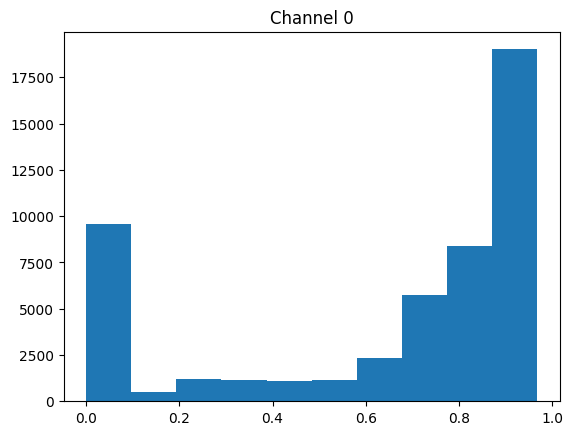

In [4]:
import matplotlib.pyplot as plt
# display the histogram of each channel
i = random.randint(0, len(train_ds))
sample, label = train_ds[1]
img = sample.numpy().transpose(1, 2, 0)
for i in range(img.shape[2]):
    plt.subplot(1, img.shape[2], i+1)
    plt.hist(img[:,:,i].flatten())
    plt.title(f'Channel {i}')
plt.show()


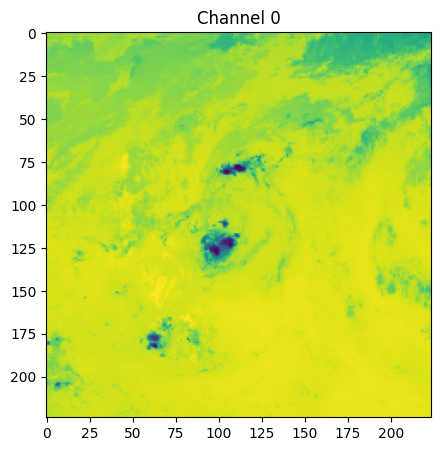

In [46]:
import matplotlib.pyplot as plt

img, label = test_ds[22]
img = img.numpy().transpose(1, 2, 0)
plt.figure(figsize=(15, 5))  # Increase the figure size for larger images
for i in range(img.shape[2]):
    plt.subplot(1, img.shape[2], i+1)
    plt.imshow(img[:,:,i], cmap='gray')
    plt.title(f'Channel {i}')
# plt.show()


plt.imshow(img)
plt.show()



In [28]:
img.min(), img.max()

(0.0, 0.9656753)

In [29]:
train_ds.dataset.transforms, val_ds.dataset.transforms, test_ds.dataset.transforms

(RegDataAugmentation(
   (transform): Sequential(
     (0): Normalize(p=1.0, p_batch=1.0, same_on_batch=True, mean=tensor([0.]), std=tensor([1.]))
     (1): RandomResizedCrop(scale=(0.8, 1.0), resize_to=(0.75, 1.3333333333333333), output_size=(224, 224), p=1.0, p_batch=1.0, same_on_batch=False, size=(224, 224), resample=bilinear, align_corners=True, cropping_mode=slice, padding_mode=zeros)
     (2): RandomHorizontalFlip(p=0.5, p_batch=1.0, same_on_batch=False)
     (3): RandomVerticalFlip(p=0.5, p_batch=1.0, same_on_batch=False)
   )
 ),
 RegDataAugmentation(
   (transform): Sequential(
     (0): Normalize(p=1.0, p_batch=1.0, same_on_batch=True, mean=tensor([0.]), std=tensor([1.]))
     (1): RandomResizedCrop(scale=(0.8, 1.0), resize_to=(0.75, 1.3333333333333333), output_size=(224, 224), p=1.0, p_batch=1.0, same_on_batch=False, size=(224, 224), resample=bilinear, align_corners=True, cropping_mode=slice, padding_mode=zeros)
     (2): RandomHorizontalFlip(p=0.5, p_batch=1.0, same_on_batc